##**Data Preprocessing**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(
    'household_power_consumption.txt',
    sep=';',
    low_memory=False
)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [3]:
print(df.shape)

df.info()

(2075259, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB


In [4]:
df.isin(['?']).sum()

,0
Date,0
Time,0
Global_active_power,25979
Global_reactive_power,25979
Voltage,25979
Global_intensity,25979
Sub_metering_1,25979
Sub_metering_2,25979
Sub_metering_3,0


In [5]:
df.replace('?', np.nan, inplace=True)

In [6]:
cols = df.columns[2:]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB


In [8]:
df['datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time']
)

/tmp/ipykernel_7524/215833874.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['datetime'] = pd.to_datetime(


In [9]:
df[['Date', 'Time', 'datetime']].head()

,Date,Time,datetime
0,16/12/2006,17:24:00,2006-12-16 17:24:00
1,16/12/2006,17:25:00,2006-12-16 17:25:00
2,16/12/2006,17:26:00,2006-12-16 17:26:00
3,16/12/2006,17:27:00,2006-12-16 17:27:00
4,16/12/2006,17:28:00,2006-12-16 17:28:00


In [10]:
df.set_index('datetime', inplace=True)

In [11]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [12]:
hourly_data = df.resample('h').mean(numeric_only=True)

In [13]:
hourly_data.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


In [14]:
hourly_data.isnull().sum()

,0
Global_active_power,421
Global_reactive_power,421
Voltage,421
Global_intensity,421
Sub_metering_1,421
Sub_metering_2,421
Sub_metering_3,421


In [15]:
hourly_data.fillna(method='ffill', inplace=True)

/tmp/ipykernel_7524/3194817397.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  hourly_data.fillna(method='ffill', inplace=True)


In [16]:
hourly_data.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,34589.000000,34589.000000,34589.000000,34589.000000,34589.000000,34589.000000,34589.000000
mean,1.089029,0.123379,240.837011,4.616290,1.123637,1.293541,6.421429
std,0.895663,0.066976,3.005611,3.749086,3.536759,4.172246,7.343298
min,0.124000,0.000000,225.834500,0.503333,0.000000,0.000000,0.000000
25%,0.342233,0.077967,239.196667,1.516667,0.000000,0.000000,0.650000
50%,0.804933,0.106933,240.965667,3.430000,0.000000,0.333333,1.650000
75%,1.575300,0.149167,242.707000,6.583333,0.000000,0.650000,14.083333
max,6.560533,0.774333,251.902000,28.383333,48.366667,46.433333,21.550000


##**EDA (Exploratory Data Analysis)**

**Electricity Consumption Trend Graph**

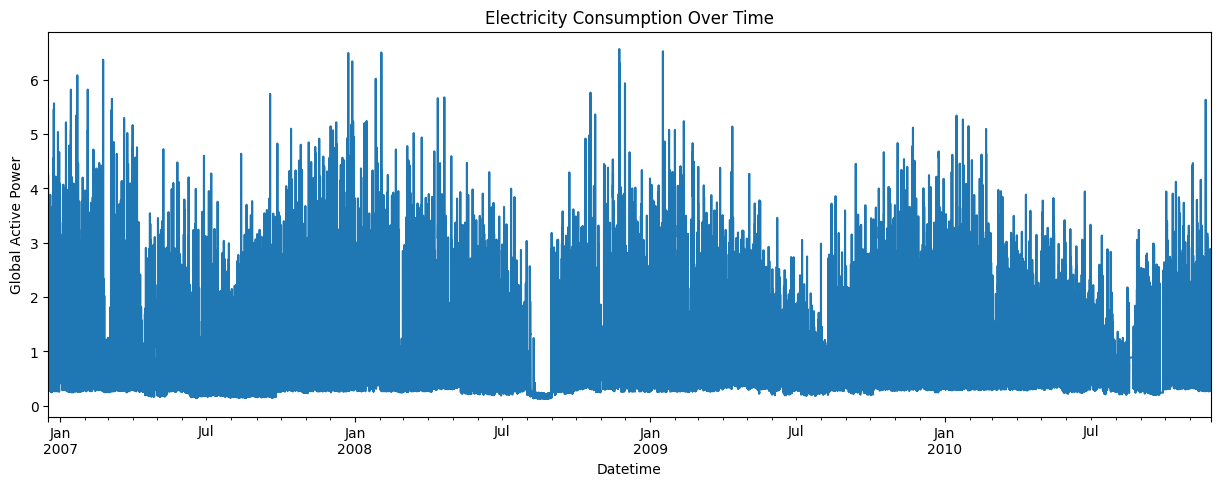

In [17]:
plt.figure(figsize=(15,5))

hourly_data['Global_active_power'].plot()

plt.title("Electricity Consumption Over Time")
plt.xlabel("Datetime")
plt.ylabel("Global Active Power")

plt.show()

**Rolling Mean Graph**

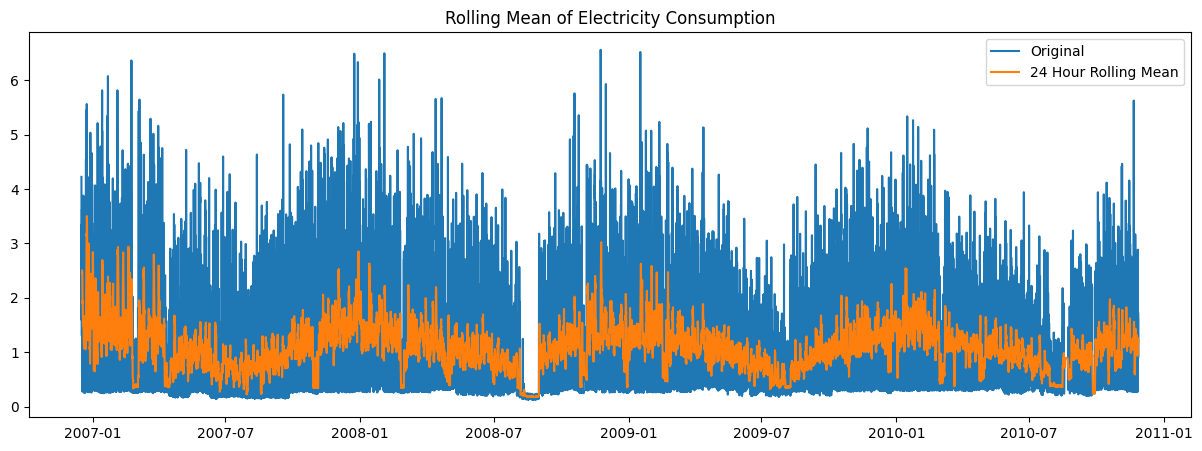

In [18]:
rolling_mean = hourly_data['Global_active_power'].rolling(window=24).mean()

plt.figure(figsize=(15,5))

plt.plot(hourly_data['Global_active_power'], label='Original')
plt.plot(rolling_mean, label='24 Hour Rolling Mean')

plt.legend()

plt.title("Rolling Mean of Electricity Consumption")

plt.show()

**Monthly Consumption Pattern**

/tmp/ipykernel_7524/4058656900.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = hourly_data['Global_active_power'].resample('M').mean()


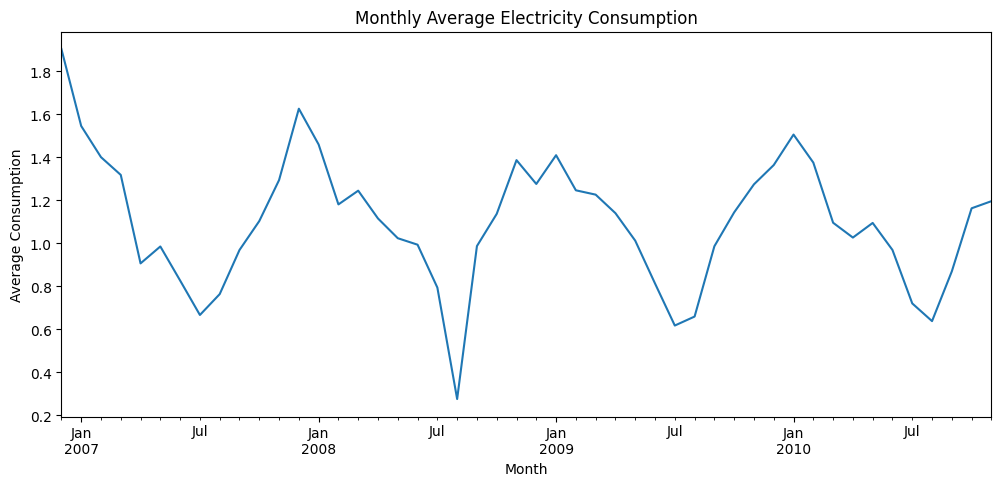

In [19]:
monthly = hourly_data['Global_active_power'].resample('M').mean()

plt.figure(figsize=(12,5))

monthly.plot()

plt.title("Monthly Average Electricity Consumption")

plt.xlabel("Month")
plt.ylabel("Average Consumption")

plt.show()

**Correlation Heatmap**

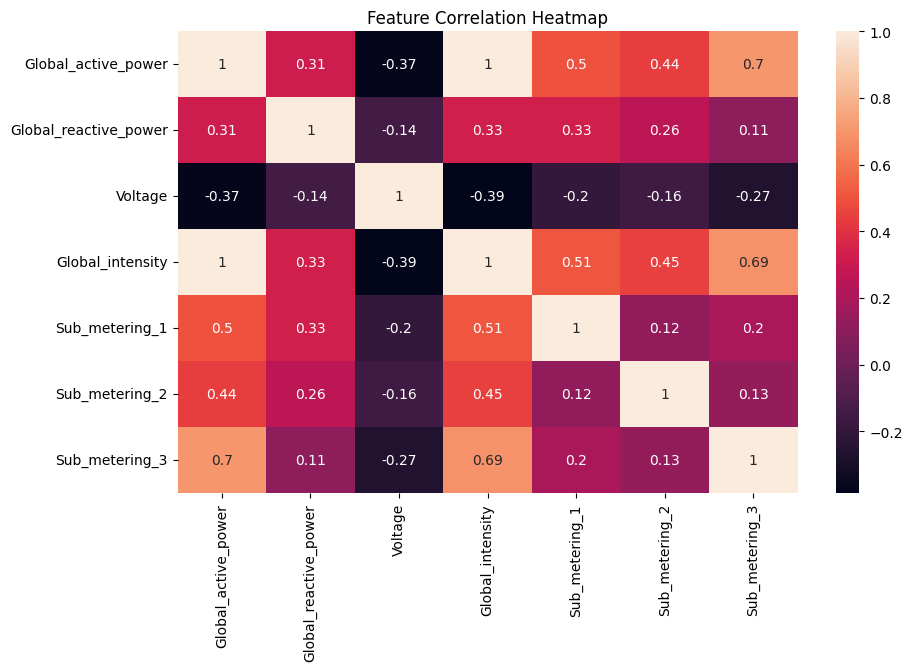

In [20]:
plt.figure(figsize=(10,6))

sns.heatmap(hourly_data.corr(), annot=True)

plt.title("Feature Correlation Heatmap")

plt.show()

##**FEATURE ENGINEERING**

In [21]:
hourly_data['hour'] = hourly_data.index.hour
hourly_data['day'] = hourly_data.index.day
hourly_data['month'] = hourly_data.index.month
hourly_data['weekday'] = hourly_data.index.weekday

In [22]:
hourly_data['lag_1'] = hourly_data['Global_active_power'].shift(1)

hourly_data['lag_24'] = hourly_data['Global_active_power'].shift(24)

In [23]:
hourly_data['rolling_mean_24'] = hourly_data['Global_active_power'].rolling(24).mean()

hourly_data['rolling_std_24'] = hourly_data['Global_active_power'].rolling(24).std()

In [24]:
hourly_data.dropna(inplace=True)

##**FORECASTING MODELS**

In [25]:
from sklearn.model_selection import train_test_split

X = hourly_data.drop('Global_active_power', axis=1)

y = hourly_data['Global_active_power']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

**Random Forest Model**

In [26]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [27]:
rf_predictions = rf_model.predict(X_test)

In [28]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, rf_predictions)

rmse = np.sqrt(
    mean_squared_error(y_test, rf_predictions)
)

r2 = r2_score(y_test, rf_predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.012800666797094401
RMSE: 0.020864483087396316
R2 Score: 0.9991824462754189


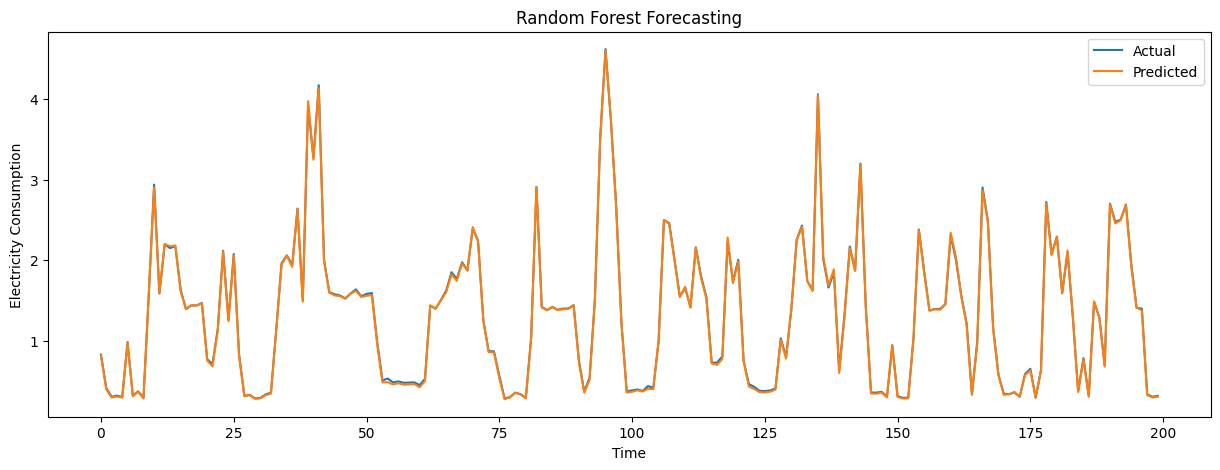

In [29]:
plt.figure(figsize=(15,5))

plt.plot(
    y_test.values[:200],
    label='Actual'
)

plt.plot(
    rf_predictions[:200],
    label='Predicted'
)

plt.legend()

plt.title("Random Forest Forecasting")

plt.xlabel("Time")

plt.ylabel("Electricity Consumption")

plt.show()

In [30]:
!pip install xgboost

In [31]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [32]:
xgb_predictions = xgb_model.predict(X_test)

In [33]:
mae = mean_absolute_error(y_test, xgb_predictions)

rmse = np.sqrt(
    mean_squared_error(y_test, xgb_predictions)
)

r2 = r2_score(y_test, xgb_predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.012345046865313248
RMSE: 0.022537651902204858
R2 Score: 0.9990460658951843


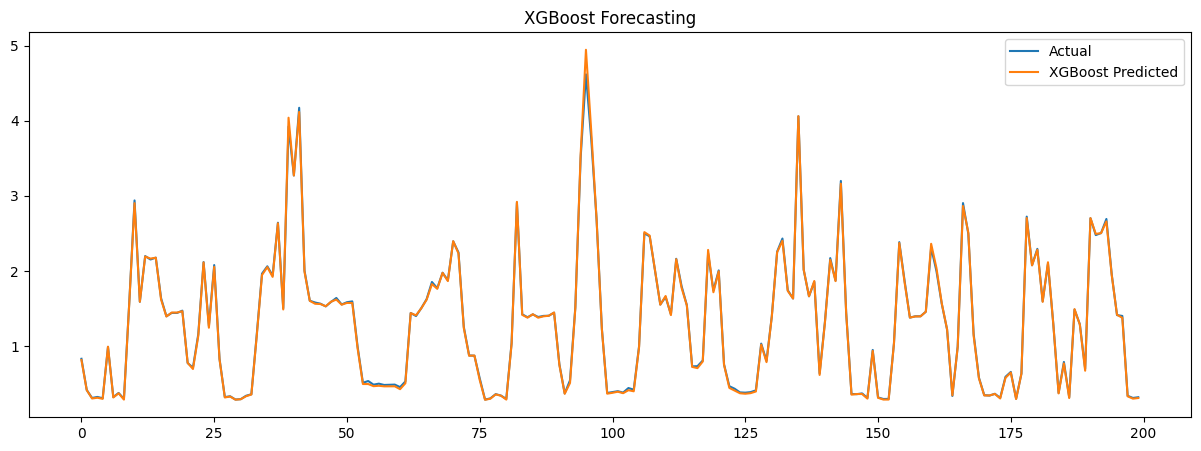

In [34]:
plt.figure(figsize=(15,5))

plt.plot(
    y_test.values[:200],
    label='Actual'
)

plt.plot(
    xgb_predictions[:200],
    label='XGBoost Predicted'
)

plt.legend()

plt.title("XGBoost Forecasting")

plt.show()

In [35]:
!pip install statsmodels

In [36]:
from statsmodels.tsa.arima.model import ARIMA

In [37]:
series = hourly_data['Global_active_power']

In [38]:
train_size = int(len(series) * 0.8)

train = series[:train_size]

test = series[train_size:]

In [39]:
arima_model = ARIMA(
    train,
    order=(5,1,0)
)

arima_result = arima_model.fit()

In [40]:
arima_predictions = arima_result.forecast(
    steps=len(test)
)

In [41]:
mae = mean_absolute_error(
    test,
    arima_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        test,
        arima_predictions
    )
)

r2 = r2_score(
    test,
    arima_predictions
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.9162350921098874
RMSE: 1.0405253896010227
R2 Score: -1.0333231521882191


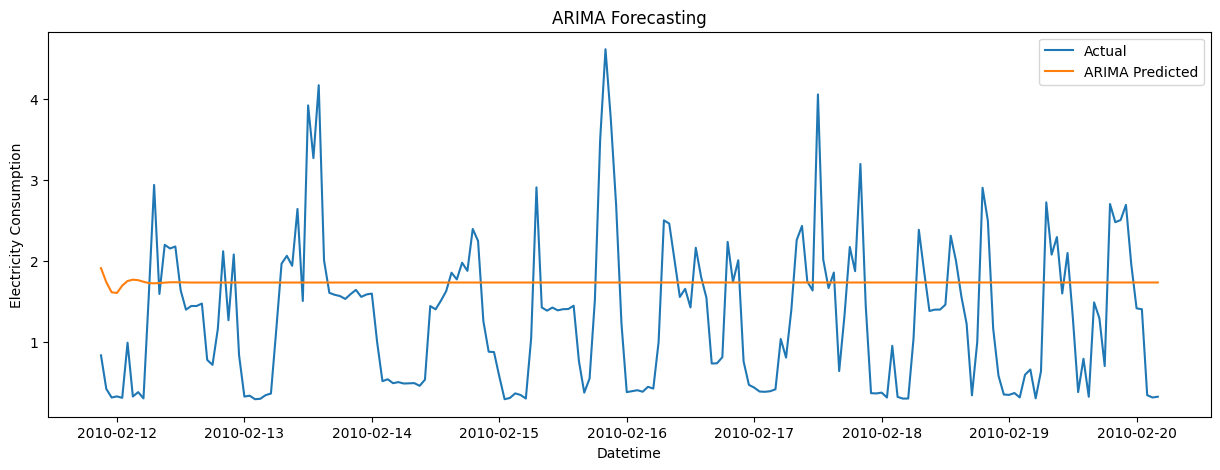

In [44]:
plt.figure(figsize=(15,5))

plt.plot(
    test.index[:200],
    test.values[:200],
    label='Actual'
)

plt.plot(
    test.index[:200],
    arima_predictions[:200],
    label='ARIMA Predicted'
)

plt.legend()

plt.title("ARIMA Forecasting")

plt.xlabel("Datetime")

plt.ylabel("Electricity Consumption")

plt.show()

##**LSTM MODEL**

In [45]:
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

from sklearn.preprocessing import MinMaxScaler

In [46]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(
    hourly_data[['Global_active_power']]
)

In [47]:
X = []
y = []

sequence_length = 24

for i in range(sequence_length, len(scaled_data)):

    X.append(
        scaled_data[i-sequence_length:i]
    )

    y.append(
        scaled_data[i]
    )

X = np.array(X)
y = np.array(y)

In [48]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [49]:
lstm_model = Sequential()

lstm_model.add(
    LSTM(
        64,
        return_sequences=False,
        input_shape=(X_train.shape[1], 1)
    )
)

lstm_model.add(Dropout(0.2))

lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [50]:
history = lstm_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
864/864 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.0126 - val_loss: 0.0069
Epoch 2/10
864/864 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0101 - val_loss: 0.0068
Epoch 3/10
864/864 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0094 - val_loss: 0.0064
Epoch 4/10
864/864 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.0092 - val_loss: 0.0063
Epoch 5/10
864/864 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0091 - val_loss: 0.0062
Epoch 6/10
864/864 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0090 - val_loss: 0.0062
Epoch 7/10
864/864 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0089 - val_loss: 0.0063
Epoch 8/10
864/864 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0089 - val_loss: 0.0062
Epoch 9/10
864/864 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0088 - val_loss: 0.0062
Epoch 10/10
864/864 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0088 - val_loss: 0.0064


In [51]:
lstm_predictions = lstm_model.predict(X_test)

216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [52]:
lstm_predictions = scaler.inverse_transform(
    lstm_predictions
)

y_test_actual = scaler.inverse_transform(
    y_test
)

In [53]:
mae = mean_absolute_error(
    y_test_actual,
    lstm_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        lstm_predictions
    )
)

r2 = r2_score(
    y_test_actual,
    lstm_predictions
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.3779043425927162
RMSE: 0.5167689940040372
R2 Score: 0.49859054815017245


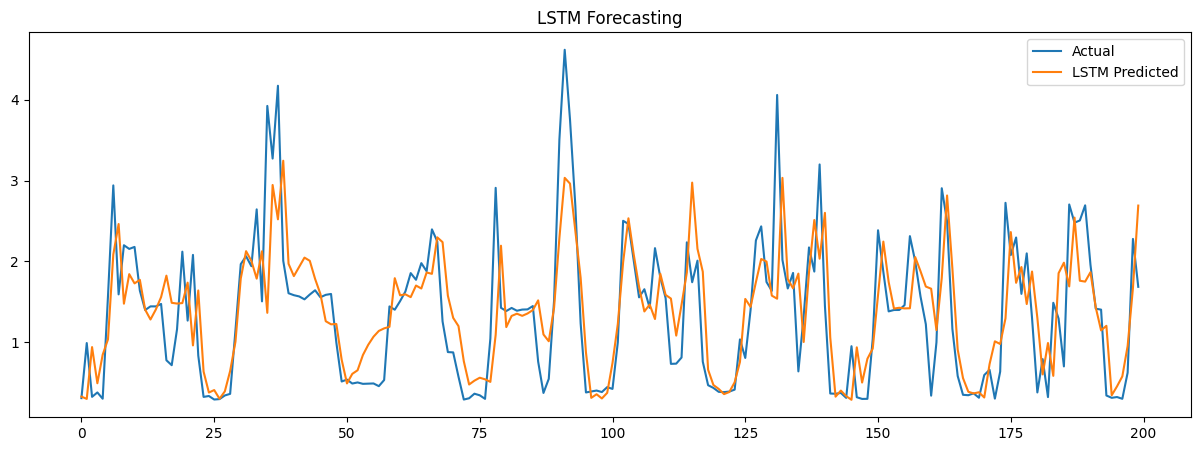

In [54]:
plt.figure(figsize=(15,5))

plt.plot(
    y_test_actual[:200],
    label='Actual'
)

plt.plot(
    lstm_predictions[:200],
    label='LSTM Predicted'
)

plt.legend()

plt.title("LSTM Forecasting")

plt.show()

##**GRU MODEL**

In [55]:
from tensorflow.keras.layers import GRU

In [56]:
gru_model = Sequential()

gru_model.add(
    GRU(
        64,
        return_sequences=False,
        input_shape=(X_train.shape[1], 1)
    )
)

gru_model.add(Dropout(0.2))

gru_model.add(Dense(1))

gru_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [57]:
history = gru_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
864/864 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0110 - val_loss: 0.0071
Epoch 2/10
864/864 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0100 - val_loss: 0.0066
Epoch 3/10
864/864 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0093 - val_loss: 0.0063
Epoch 4/10
864/864 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.0092 - val_loss: 0.0063
Epoch 5/10
864/864 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.0091 - val_loss: 0.0066
Epoch 6/10
864/864 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0091 - val_loss: 0.0062
Epoch 7/10
864/864 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0089 - val_loss: 0.0064
Epoch 8/10
864/864 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0089 - val_loss: 0.0064
Epoch 9/10
864/864 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0089 - val_loss: 0.0061
Epoch 10/10
864/864 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0089 - val_loss: 0.0063


In [58]:
gru_predictions = gru_model.predict(X_test)

216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [59]:
gru_predictions = scaler.inverse_transform(
    gru_predictions
)

y_test_actual = scaler.inverse_transform(
    y_test
)

In [60]:
mae = mean_absolute_error(
    y_test_actual,
    gru_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        gru_predictions
    )
)

r2 = r2_score(
    y_test_actual,
    gru_predictions
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.36130557336603025
RMSE: 0.5112401305751424
R2 Score: 0.5092622197394178


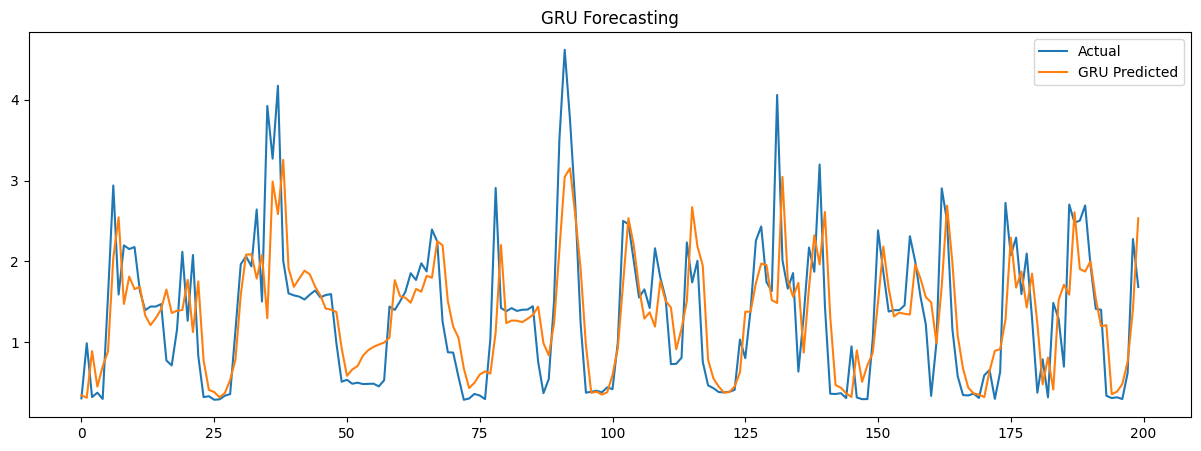

In [61]:
plt.figure(figsize=(15,5))

plt.plot(
    y_test_actual[:200],
    label='Actual'
)

plt.plot(
    gru_predictions[:200],
    label='GRU Predicted'
)

plt.legend()

plt.title("GRU Forecasting")

plt.show()

##**ANOMALY DETECTION**

**STEP 1 — Z-Score Anomaly Detection**

In [62]:
from scipy.stats import zscore

hourly_data['zscore'] = zscore(
    hourly_data['Global_active_power']
)

**STEP 2 — Detect Anomalies**

In [63]:
anomalies = hourly_data[
    abs(hourly_data['zscore']) > 3
]

**STEP 3 — Count Anomalies**"

In [64]:
print("Total anomalies:", len(anomalies))

Total anomalies: 438


**STEP 4 — Plot Anomal**

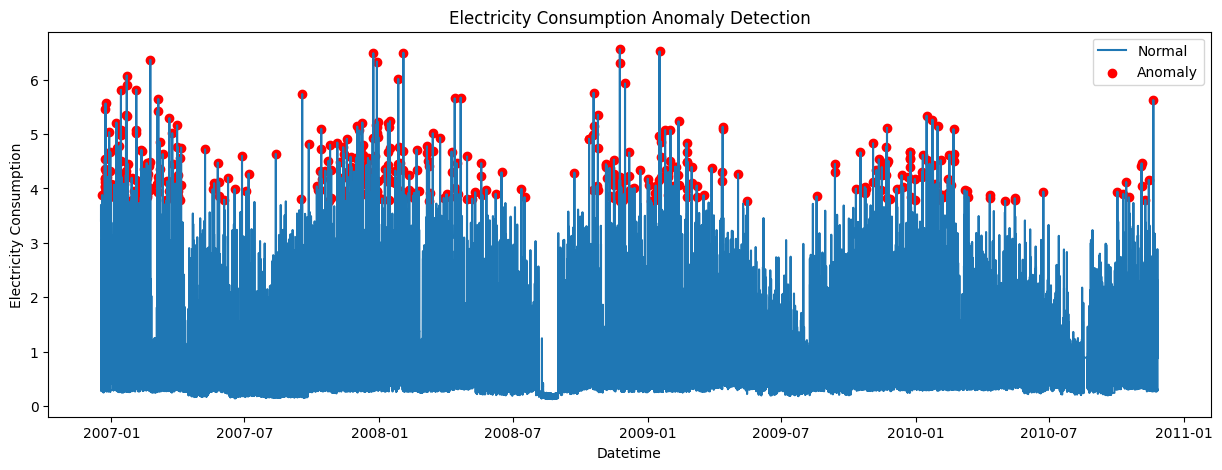

In [65]:
plt.figure(figsize=(15,5))

plt.plot(
    hourly_data.index,
    hourly_data['Global_active_power'],
    label='Normal'
)

plt.scatter(
    anomalies.index,
    anomalies['Global_active_power'],
    color='red',
    label='Anomaly'
)

plt.legend()

plt.title("Electricity Consumption Anomaly Detection")

plt.xlabel("Datetime")

plt.ylabel("Electricity Consumption")

plt.show()

##**MODEL COMPARISON TABLE**

**STEP 1 — Create Comparison Table**

In [66]:
comparison = pd.DataFrame({

    'Model': [
        'Random Forest',
        'XGBoost',
        'ARIMA',
        'LSTM',
        'GRU'
    ],

    'MAE': [
        0.0128,
        0.0123,
        0.916,
        0.377,
        0.361
    ],

    'RMSE': [
        0.0208,
        0.0225,
        1.04,
        0.516,
        0.511
    ],

    'R2 Score': [
        0.9991,
        0.9990,
        -1.03,
        0.498,
        0.509
    ]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Random Forest,0.0128,0.0208,0.9991
1,XGBoost,0.0123,0.0225,0.9990
2,ARIMA,0.9160,1.0400,-1.0300
3,LSTM,0.3770,0.5160,0.4980
4,GRU,0.3610,0.5110,0.5090


**STEP 2 — Plot Model Comparison**

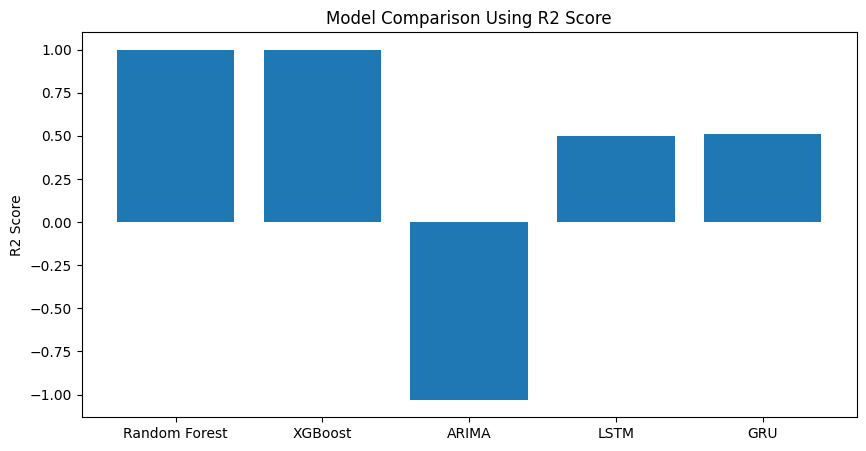

In [67]:
plt.figure(figsize=(10,5))

plt.bar(
    comparison['Model'],
    comparison['R2 Score']
)

plt.title("Model Comparison Using R2 Score")

plt.ylabel("R2 Score")

plt.show()

In [68]:
hourly_data.to_csv(
    "final_electricity_dataset.csv"
)